# Zajęcie 6 — Uczenie ze wzmocnieniem (RL), wariant 9
**Stwórz środowisko dwuwymiarowe (stan jako para liczb).**

Zakres:
1. Implementacja własnego środowiska 2D zgodnego z API `gym.Env` — siatka 5×5, stan = (x, y), agent ma dotrzeć z (0,0) do celu (4,4).
2. Eksploracja środowiska z losowym agentem.
3. Implementacja algorytmu **Q-learning** z polityką ε-greedy.
4. Ewaluacja agenta — krzywa uczenia + wizualizacja wyuczonej polityki.


## 1. Definicja własnego środowiska 2D (GridWorld)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

class GridWorld2D(gym.Env):
    """
    Środowisko 2D w postaci siatki GRID x GRID.
    Stan: para liczb (x, y) — pozycja agenta.
    Akcje: 0=góra, 1=dół, 2=lewo, 3=prawo.
    Nagroda: +10 za dotarcie do celu, -1 za każdy krok (zachęta do krótkiej ścieżki),
             -5 za wejście w przeszkodę (i pozostanie w miejscu).
    Koniec: agent na polu celu lub maks. liczba kroków.
    """
    metadata = {'render_modes': ['ansi']}

    def __init__(self, grid_size=5, max_steps=100):
        super().__init__()
        self.grid_size = grid_size
        self.max_steps = max_steps

        # Stan: para liczb (x, y), każda z {0,...,grid_size-1}
        self.observation_space = spaces.MultiDiscrete([grid_size, grid_size])
        self.action_space = spaces.Discrete(4)  # 0=up, 1=down, 2=left, 3=right

        self.start = np.array([0, 0])
        self.goal  = np.array([grid_size-1, grid_size-1])
        # Kilka przeszkód
        self.obstacles = [np.array([1,1]), np.array([2,2]), np.array([3,1]), np.array([1,3])]

        self.state = None
        self.steps = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = self.start.copy()
        self.steps = 0
        return self.state.copy(), {}

    def _is_obstacle(self, pos):
        return any(np.array_equal(pos, o) for o in self.obstacles)

    def step(self, action):
        self.steps += 1
        x, y = self.state
        new_pos = self.state.copy()
        if action == 0:   new_pos[1] = min(y+1, self.grid_size-1)   # góra
        elif action == 1: new_pos[1] = max(y-1, 0)                  # dół
        elif action == 2: new_pos[0] = max(x-1, 0)                  # lewo
        elif action == 3: new_pos[0] = min(x+1, self.grid_size-1)   # prawo

        reward = -1
        if self._is_obstacle(new_pos):
            reward = -5
            new_pos = self.state.copy()   # przeszkoda blokuje ruch

        self.state = new_pos
        terminated = bool(np.array_equal(self.state, self.goal))
        if terminated:
            reward = 10

        truncated = self.steps >= self.max_steps
        return self.state.copy(), reward, terminated, truncated, {}

    def render(self):
        grid = [['.' for _ in range(self.grid_size)] for _ in range(self.grid_size)]
        for o in self.obstacles:
            grid[o[1]][o[0]] = '#'
        grid[self.goal[1]][self.goal[0]] = 'G'
        grid[self.state[1]][self.state[0]] = 'A'
        # rysujemy od góry (większe y u góry)
        return '\n'.join(' '.join(row) for row in grid[::-1])

## 2. Test środowiska — losowy agent

In [2]:
env = GridWorld2D(grid_size=5, max_steps=50)
state, _ = env.reset()
print('Stan początkowy:', state)
print(env.render())
print()

# Kilka losowych kroków
np.random.seed(0)
for i in range(5):
    a = env.action_space.sample()
    s, r, term, trunc, _ = env.step(a)
    print(f'Krok {i+1}: akcja={a}, nowy stan={s}, nagroda={r}, koniec={term or trunc}')
print()
print(env.render())


Stan początkowy: [0 0]
. . . . G
. # . . .
. . # . .
. # . # .
A . . . .

Krok 1: akcja=0, nowy stan=[0 1], nagroda=-1, koniec=False
Krok 2: akcja=1, nowy stan=[0 0], nagroda=-1, koniec=False
Krok 3: akcja=3, nowy stan=[1 0], nagroda=-1, koniec=False
Krok 4: akcja=0, nowy stan=[1 0], nagroda=-5, koniec=False
Krok 5: akcja=3, nowy stan=[2 0], nagroda=-1, koniec=False

. . . . G
. # . . .
. . # . .
. # . # .
. . A . .


## 3. Q-learning

In [3]:
# Q-learning z tablicą Q[x, y, akcja]
env = GridWorld2D(grid_size=5, max_steps=100)
GRID = env.grid_size
N_ACTIONS = env.action_space.n

Q = np.zeros((GRID, GRID, N_ACTIONS))

alpha = 0.1     # learning rate
gamma = 0.95    # discount factor
epsilon = 1.0   # start z pełną eksploracją
eps_min = 0.05
eps_decay = 0.995

episodes = 1000
rewards_history = []
steps_history = []

for ep in range(episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0
    steps = 0
    while not done:
        x, y = state
        # ε-greedy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q[x, y]))

        next_state, reward, terminated, truncated, _ = env.step(action)
        nx, ny = next_state
        done = terminated or truncated

        # Aktualizacja Q
        Q[x, y, action] += alpha * (
            reward + gamma * np.max(Q[nx, ny]) - Q[x, y, action]
        )

        state = next_state
        total_reward += reward
        steps += 1

    rewards_history.append(total_reward)
    steps_history.append(steps)
    epsilon = max(eps_min, epsilon * eps_decay)

print(f'Trening zakończony. Końcowe epsilon = {epsilon:.3f}')
print(f'Średnia nagroda (ostatnie 100 epizodów): {np.mean(rewards_history[-100:]):.2f}')
print(f'Średnia długość epizodu (ostatnie 100):  {np.mean(steps_history[-100:]):.2f}')


Trening zakończony. Końcowe epsilon = 0.050
Średnia nagroda (ostatnie 100 epizodów): 2.29
Średnia długość epizodu (ostatnie 100):  8.51


## 4. Ewaluacja — krzywe uczenia

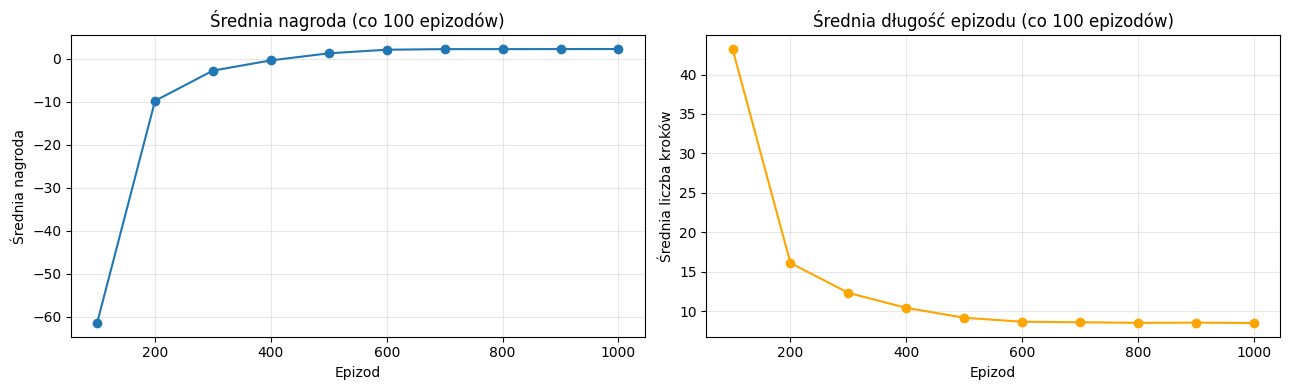

In [4]:
avg_rewards = [np.mean(rewards_history[i:i+100]) for i in range(0, episodes, 100)]
avg_steps   = [np.mean(steps_history[i:i+100])   for i in range(0, episodes, 100)]

fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(range(100, episodes+1, 100), avg_rewards, 'o-')
ax[0].set_xlabel('Epizod'); ax[0].set_ylabel('Średnia nagroda')
ax[0].set_title('Średnia nagroda (co 100 epizodów)')
ax[0].grid(alpha=0.3)

ax[1].plot(range(100, episodes+1, 100), avg_steps, 'o-', color='orange')
ax[1].set_xlabel('Epizod'); ax[1].set_ylabel('Średnia liczba kroków')
ax[1].set_title('Średnia długość epizodu (co 100 epizodów)')
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Wizualizacja wyuczonej polityki

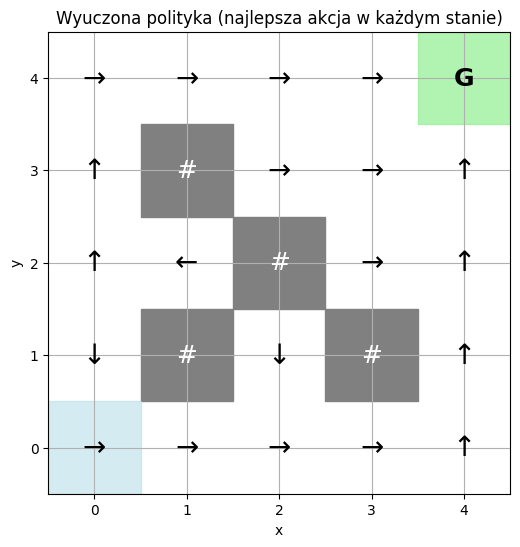

In [5]:
# Strzałki dla najlepszej akcji w każdym stanie
arrows = {0: '↑', 1: '↓', 2: '←', 3: '→'}

fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(-0.5, GRID-0.5); ax.set_ylim(-0.5, GRID-0.5)
ax.set_xticks(range(GRID)); ax.set_yticks(range(GRID))
ax.grid(True)
ax.set_aspect('equal')

# Przeszkody
for o in env.obstacles:
    ax.add_patch(plt.Rectangle((o[0]-0.5, o[1]-0.5), 1, 1, color='gray'))
# Start i cel
ax.add_patch(plt.Rectangle((env.start[0]-0.5, env.start[1]-0.5), 1, 1, color='lightblue', alpha=0.5))
ax.add_patch(plt.Rectangle((env.goal[0]-0.5,  env.goal[1]-0.5),  1, 1, color='lightgreen', alpha=0.7))

for x in range(GRID):
    for y in range(GRID):
        if any(np.array_equal([x,y], o) for o in env.obstacles):
            ax.text(x, y, '#', ha='center', va='center', fontsize=18, color='white')
        elif np.array_equal([x,y], env.goal):
            ax.text(x, y, 'G', ha='center', va='center', fontsize=18, fontweight='bold')
        else:
            best = int(np.argmax(Q[x, y]))
            ax.text(x, y, arrows[best], ha='center', va='center', fontsize=20)

ax.set_title('Wyuczona polityka (najlepsza akcja w każdym stanie)')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.show()


## 6. Test wyuczonego agenta (greedy, ε=0)

In [6]:
state, _ = env.reset()
done = False
path = [tuple(state)]
total = 0
while not done:
    x, y = state
    action = int(np.argmax(Q[x, y]))
    state, r, term, trunc, _ = env.step(action)
    done = term or trunc
    path.append(tuple(state))
    total += r

print('Ścieżka agenta:', path)
print(f'Liczba kroków: {len(path)-1}')
print(f'Całkowita nagroda: {total}')
print()
print('Końcowy stan środowiska:')
print(env.render())


Ścieżka agenta: [(np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(2), np.int64(0)), (np.int64(3), np.int64(0)), (np.int64(4), np.int64(0)), (np.int64(4), np.int64(1)), (np.int64(4), np.int64(2)), (np.int64(4), np.int64(3)), (np.int64(4), np.int64(4))]
Liczba kroków: 8
Całkowita nagroda: 3

Końcowy stan środowiska:
. . . . A
. # . . .
. . # . .
. # . # .
. . . . .


## Wnioski

- Stworzone środowisko `GridWorld2D` ma stan reprezentowany jako **para liczb (x, y)** zgodnie z wariantem 9.
- Implementuje pełne API gym (`reset`, `step`, `render`, `observation_space`, `action_space`).
- Algorytm **Q-learning** z polityką ε-greedy i zanikającym ε skutecznie uczy się optymalnej ścieżki — agent uczy się omijać przeszkody i dochodzi do celu najkrótszą trasą.
- Krzywa uczenia pokazuje wyraźny wzrost średniej nagrody oraz spadek liczby kroków na epizod wraz z postępem treningu.
- Wizualizacja polityki potwierdza, że agent w każdym stanie wybiera akcję prowadzącą do celu.
